**Lab 5 : Non-linear Binary Classification using Neural Networks**

---
```
The objective of this lab is to build a neural network capable of classifying data that is not linearly separable, and to understand why non-linear activation functions are necessary for this task.
```
```
Students will generate a non-linear 2D dataset, build a multi-layer neural network using PyTorch's nn.Module, train it with BCEWithLogitsLoss and SGD, and visualize the model's decision boundary before and after training
```



In [2]:
import torch
torch.__version__

'2.6.0+cu124'

In [3]:
device = ''
if torch.cuda.is_available():
    device="cuda"
elif torch.backend.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device = {device}")

Using device = cuda


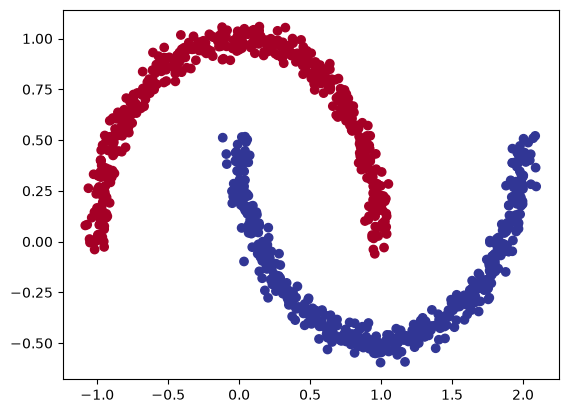

In [4]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
n_samples = 1000
X, y = make_moons(n_samples=n_samples,noise=0.04,random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [5]:
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size= 0.2, random_state=42)

In [6]:
from torch import nn

class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU()

    def forward(self, X):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(X)))))

In [7]:
torch.manual_seed(42)
model = CircleModel()
print(model.state_dict())

OrderedDict([('layer_1.weight', tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188],
        [ 0.6146,  0.1323],
        [ 0.5224,  0.0958],
        [ 0.3410, -0.0998],
        [ 0.5451,  0.1045],
        [-0.3301,  0.1802]])), ('layer_1.bias', tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
         0.0667, -0.6984])), ('layer_2.weight', tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
          0.0346, -0.0997],
        [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
          0.1606, -0.1927],
        [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1310,  0.1000, -0.0055,
          0.2475, -0.2247],
        [ 0.0199, -0.2158,  0.0975, -0.1089,  0.0969, -0.0659,  0.2623, -0.1874,
         -0.1886, -0.1886],
        [ 0.2844,  0.1054,  0.3043, -0.2610, -0.3137, -0.2474, -0.2127,  0.1281,
          0.1132,  0.26

In [8]:
n_of_params = 0
state_dict = model.state_dict()
n_of_params = sum(v.numel() for v in state_dict.values())
print("Number of parameters:", n_of_params)


Number of parameters: 151


In [9]:
# set up loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    params = model.parameters(),
    lr = 0.1
)

In [10]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_true))*100
    return acc

In [11]:
epochs = 3000
train_loss_list = []
test_loss_list = []
model.to(device)
X_train , y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
for epoch in range(epochs):
    #### Training
    model.train()
    # 1. Forward bias
    train_logits = model(X_train).squeeze()
    train_preds = torch.round(torch.sigmoid(train_logits))
    train_loss = loss_fn(train_logits, y_train)
    train_acc = accuracy_fn(y_true=y_train,y_pred=train_preds)
    # 2. ZERO GRAD THE OPTIMIZER
    optimizer.zero_grad()
    #3.Compute the gradients
    train_loss.backward()
    #4.update the weight
    optimizer.step()
    #### TESTING
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)
    train_loss_list.append(train_loss.item())
    test_loss_list.append(test_loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}|Loss {train_loss:.5f}|Acc {train_acc:.2f}|Test Loss {test_loss:.5f}|Test Acc {test_acc:.2f}')


Epoch 100|Loss 0.38976|Acc 81.75|Test Loss 0.40503|Test Acc 76.50
Epoch 200|Loss 0.23849|Acc 88.38|Test Loss 0.23875|Test Acc 90.00
Epoch 300|Loss 0.19304|Acc 91.00|Test Loss 0.18643|Test Acc 92.50
Epoch 400|Loss 0.15458|Acc 93.62|Test Loss 0.14636|Test Acc 93.50
Epoch 500|Loss 0.11058|Acc 95.38|Test Loss 0.10202|Test Acc 97.00
Epoch 600|Loss 0.07233|Acc 98.25|Test Loss 0.06510|Test Acc 99.00
Epoch 700|Loss 0.04671|Acc 99.25|Test Loss 0.04116|Test Acc 99.50
Epoch 800|Loss 0.03204|Acc 99.88|Test Loss 0.02759|Test Acc 100.00
Epoch 900|Loss 0.02344|Acc 100.00|Test Loss 0.01990|Test Acc 100.00
Epoch 1000|Loss 0.01804|Acc 100.00|Test Loss 0.01510|Test Acc 100.00
Epoch 1100|Loss 0.01445|Acc 100.00|Test Loss 0.01195|Test Acc 100.00
Epoch 1200|Loss 0.01194|Acc 100.00|Test Loss 0.00977|Test Acc 100.00
Epoch 1300|Loss 0.01010|Acc 100.00|Test Loss 0.00820|Test Acc 100.00
Epoch 1400|Loss 0.00871|Acc 100.00|Test Loss 0.00704|Test Acc 100.00
Epoch 1500|Loss 0.00762|Acc 100.00|Test Loss 0.00614|Test 

Text(0.5, 1.0, 'Epochs vs Loss')

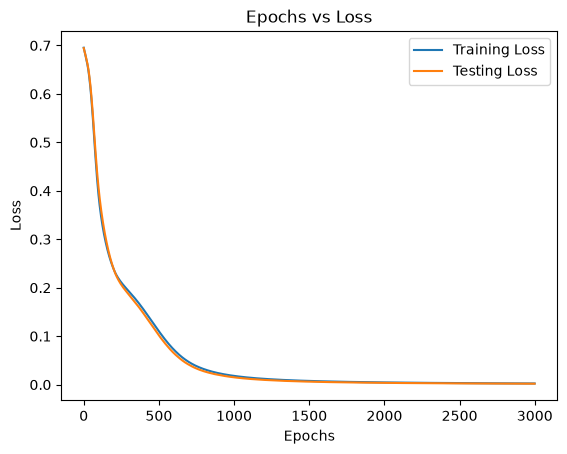

In [12]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Epochs vs Loss")

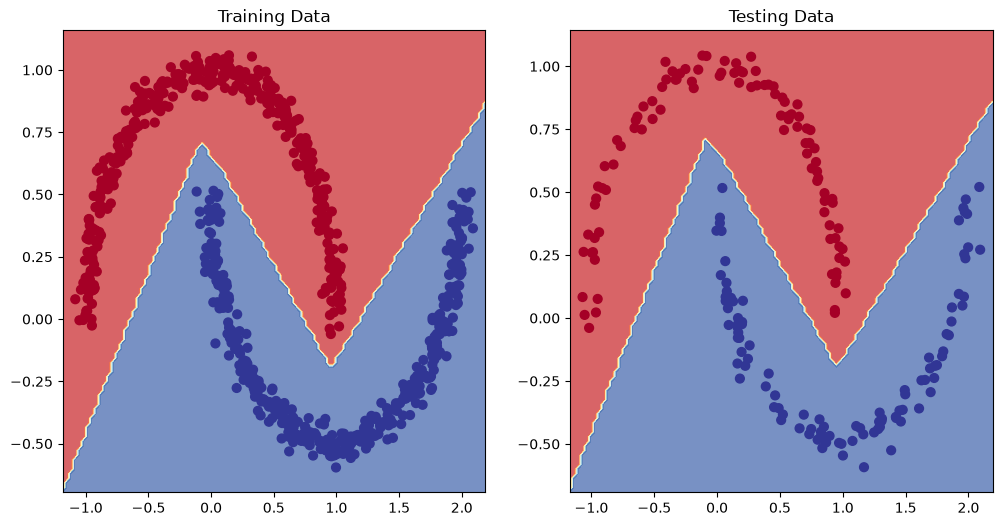

In [13]:
from helper_functions import plot_decision_boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)